In [1]:
import numpy as np
import sys
%load_ext autoreload
%autoreload 2
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/chainedQR/EnergyFlow/")
from energyflow.archs import EFN, PFN
import matplotlib.pyplot as plt
import h5py
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
import torch
import torch.nn as nn
device = torch.device('cuda:0')
from edgeconv import EdgeConvBlock, ParticleNet
sys.path.append("quantiledatamc/auc95_pn_ctr/")
from run_pnet import simple_MLP, load_parts, PNetWrapper
pnet_classifier = torch.load("quantiledatamc/end_gpu_base_satori_full.pt").to(device)

# ParticleNet stuff (jet 1 only)

In [2]:
## Function to load jet 1 HL variables
def load_hl(filename,vars,cutoff=False):
    h5file = h5py.File(filename, 'r') # open read-only
    print(h5file.keys())
    out = []
    for v in vars:
        out.append(h5file[v][()].reshape(-1,1))
    return np.concatenate(out,axis=1)

# Loading particle-level variables
bb1_ftest = "/nobackup/users/sambt/QR_samples/LHCO/challenge/BB1/bkg_particleNet_test_sample.h5"
rd_ftest = "/nobackup/users/sambt/QR_samples/LHCO/rd/RD/bkg_particleNet_test_sample.h5"
b1_test = load_parts(bb1_ftest,cutoff=False)
rd_test = load_parts(rd_ftest,cutoff=False)

# Loading HL variables
vars = ['jet1_pt','jet1_m','jet1_tau21','jet1_tau32','jet1_tau43']
vars_b1 = load_hl(bb1_ftest,vars)
vars_rd = load_hl(rd_ftest,vars)
rho_b1 = vars_b1[:,1]/vars_b1[:,0]
rho_rd = vars_rd[:,1]/vars_rd[:,0]
rd_hl_vars = np.concatenate((rho_rd.reshape(-1,1),vars_rd[:,2:]),axis=1)
b1_hl_vars = np.concatenate((rho_b1.reshape(-1,1),vars_b1[:,2:]),axis=1)
del vars_b1, vars_rd, rho_b1, rho_rd

# standardizing particle variables
with h5py.File("quantiledatamc/meanstd.h5","r") as f:
    tot1m = f['tot1m'][()]
    tot1s = f['tot1s'][()]
b1_test = (b1_test-tot1m)/tot1s
rd_test = (rd_test-tot1m)/tot1s

# loading nets
pnet_embed = torch.load("quantiledatamc/end_gpu_encodor_satori_full.pt")
pnet_wgt = torch.load("reweighting_methods/particlenet_rdVsBB1_toReweightRD.pt")

# evaluating embeddings
split_b1 = np.array_split(np.arange(len(b1_test)),b1_test.shape[0]//1000)
split_rd = np.array_split(np.arange(len(rd_test)),b1_test.shape[0]//1000)

embed_b1 = []
embed_rd = []
pnet_embed = pnet_embed.to(device)
for s in split_b1:
    embed_b1.append(pnet_embed(torch.tensor(b1_test[s],dtype=torch.float32,device=device)).detach().cpu().numpy())
embed_b1 = np.concatenate(embed_b1,axis=0)
for s in split_rd:
    embed_rd.append(pnet_embed(torch.tensor(rd_test[s],dtype=torch.float32,device=device)).detach().cpu().numpy())
embed_rd = np.concatenate(embed_rd,axis=0)
pnet_embed = pnet_embed.to('cpu')

# evaluating weights from classifier NN
pnet_wgt = pnet_wgt.to(device)
wgts_rd = []
for s in split_rd:
    wgts_rd.append(pnet_wgt(torch.tensor(rd_test[s],dtype=torch.float32,device=device)).detach().cpu().numpy())
wgts_rd = np.concatenate(wgts_rd,axis=0)[:,0]
wgts_rd = wgts_rd/(1-wgts_rd)

/nobackup/users/sambt/QR_samples/LHCO/challenge/BB1/bkg_particleNet_test_sample.h5 <KeysViewHDF5 ['ce', 'ceta', 'cphi', 'cpt', 'cz', 'cze', 'jet1_eta', 'jet1_m', 'jet1_phi', 'jet1_pt', 'jet1_tau21', 'jet1_tau32', 'jet1_tau43']>
/nobackup/users/sambt/QR_samples/LHCO/rd/RD/bkg_particleNet_test_sample.h5 <KeysViewHDF5 ['ce', 'ceta', 'cphi', 'cpt', 'cz', 'cze', 'jet1_eta', 'jet1_m', 'jet1_phi', 'jet1_pt', 'jet1_tau21', 'jet1_tau32', 'jet1_tau43']>
<KeysViewHDF5 ['ce', 'ceta', 'cphi', 'cpt', 'cz', 'cze', 'jet1_eta', 'jet1_m', 'jet1_phi', 'jet1_pt', 'jet1_tau21', 'jet1_tau32', 'jet1_tau43']>
<KeysViewHDF5 ['ce', 'ceta', 'cphi', 'cpt', 'cz', 'cze', 'jet1_eta', 'jet1_m', 'jet1_phi', 'jet1_pt', 'jet1_tau21', 'jet1_tau32', 'jet1_tau43']>


/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
/home/sambt/.local/lib/python3.7/site-packages/ipykernel_launcher.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


In [3]:
# correcting jet 1 HL variables using morphing
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"
fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']
fitvarNames = [r"Jet 1 $\rho$",r"Jet 1 $\tau_{21}$",r"Jet 1 $\tau_{32}$",r"Jet 1 $\tau_{43}$",
               r"Jet 2 $\rho$",r"Jet 2 $\tau_{21}$",r"Jet 2 $\tau_{32}$",r"Jet 2 $\tau_{43}$"]
with h5py.File(f_ind_rd,'r') as f:
    rd_test_idx = f['test_inds'][()]
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd_test = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_test_idx]
model_dir = "LHCO_BB1toPythRD_jets12"
corrector = qrnn.chainedNFCorrector(f"NF_models_QR_general/{model_dir}/")
corr_rd_test = corrector.invertFull(rd_test)
corr_rd_test = np.concatenate([corr_rd_test[v] for v in fitvars],axis=1)

[0, 1, 2, 3, 4, 5, 6]


100%|██████████| 26/26 [00:00<00:00, 26.34it/s]


[0, 1, 2, 3, 4, 5]


100%|██████████| 26/26 [00:00<00:00, 27.74it/s]


[0, 1, 2, 3, 4]


...

100%|██████████| 26/26 [00:00<00:00, 30.19it/s]


[0]


100%|██████████| 26/26 [00:00<00:00, 30.64it/s]


[]


100%|██████████| 26/26 [00:00<00:00, 30.09it/s]


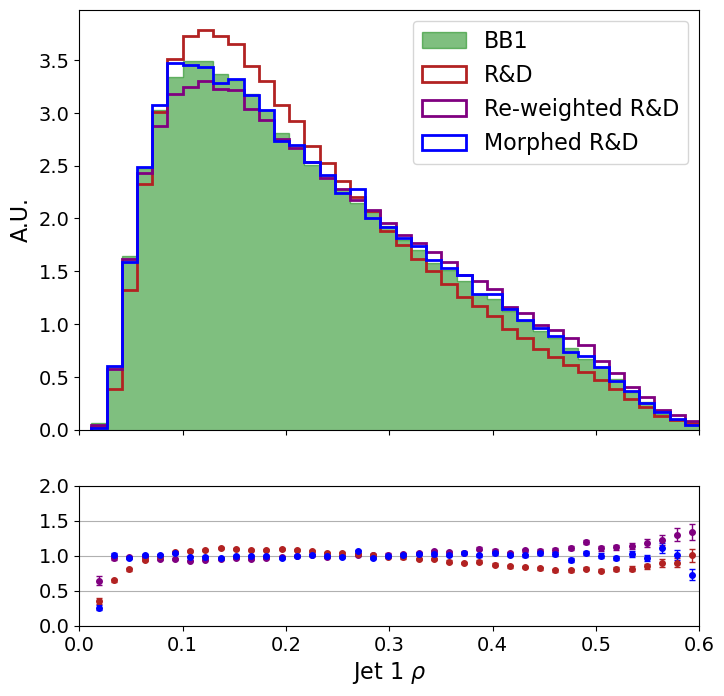

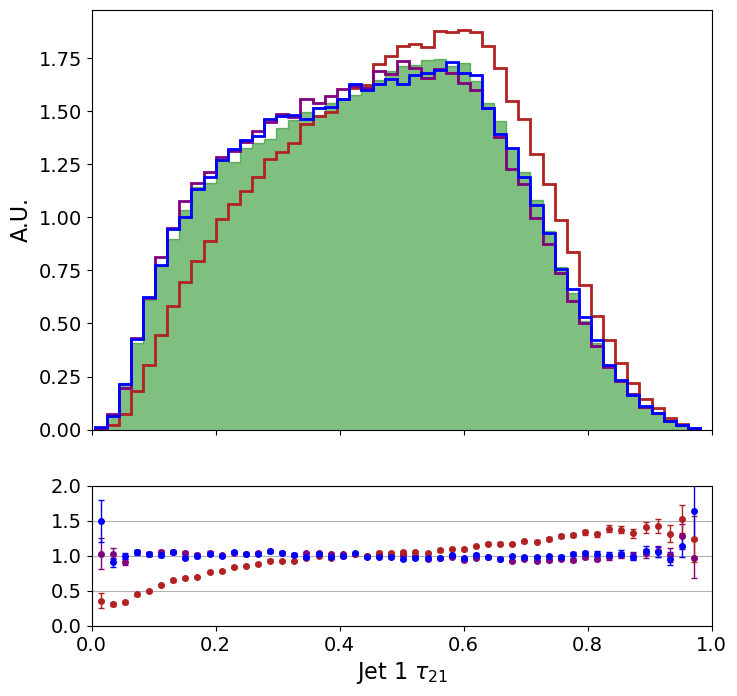

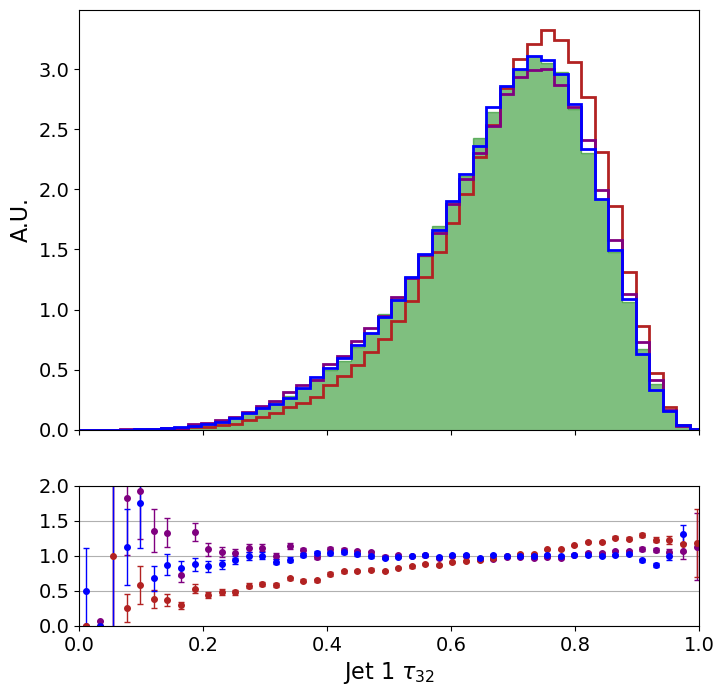

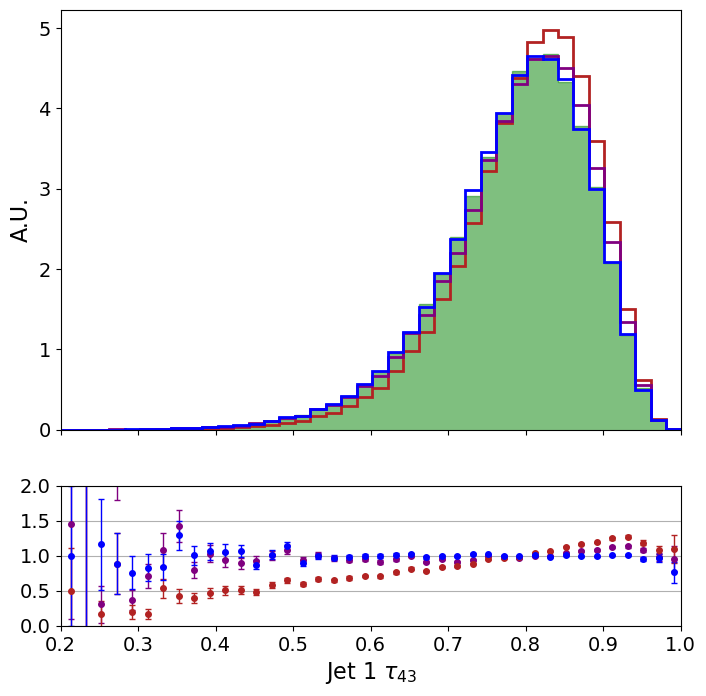

In [6]:
xlims = [[0,0.6],[0,1],[0,1],[0.2,1]]
xlims = xlims+xlims
msize=8
cthick=1
csize=2
elw = 1
varNames = [r"Jet 1 $\rho$",r"Jet 1 $\tau_{21}$",r"Jet 1 $\tau_{32}$",r"Jet 1 $\tau_{43}$"]
fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43']
import os
if not os.path.isdir("reweighting_methods/comparison_particleNet_jet1"):
    os.mkdir("reweighting_methods/comparison_particleNet_jet1")
for i in range(rd_hl_vars.shape[1]):
    fig,axes = plt.subplots(figsize=(8,8),nrows=2,ncols=1,gridspec_kw={'height_ratios':[3,1]},sharex=True)
    plt.sca(axes[0])
    bins = 50
    h1,bins,_ = plt.hist(b1_hl_vars[:,i],bins=bins,histtype='step',label='BB1',density=True,color='green',fill=True,alpha=0.5)
    h3,bins,_ = plt.hist(rd_hl_vars[:,i],bins=bins,histtype='step',label='R&D',density=True,color='firebrick',linewidth=2)
    h2,bins,_ = plt.hist(rd_hl_vars[:,i],weights=wgts_rd,bins=bins,histtype='step',label='Re-weighted R&D',density=True,color='purple',linewidth=2)
    h4,bins,_ = plt.hist(corr_rd_test[:,i],bins=bins,histtype='step',label='Morphed R&D',density=True,color='blue',linewidth=2)
    h1c,bins = np.histogram(b1_hl_vars[:,i],bins=bins)
    h3c,bins = np.histogram(rd_hl_vars[:,i],bins=bins)
    h2c,bins = np.histogram(rd_hl_vars[:,i],weights=wgts_rd,bins=bins)
    h4c,bins = np.histogram(corr_rd_test[:,i],bins=bins)
    plt.xlim(xlims[i])
    plt.ylabel("A.U.",fontsize=16)
    plt.yticks(fontsize=14)
    if i==0 or i==4:
        plt.legend(fontsize=16)
    plt.sca(axes[1])
    w = bins[1]-bins[0]
    c = (bins[1:]+bins[:-1])/2
    h = np.divide(h2,h1,where=h1>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,h2c.astype(np.float32),out=np.zeros_like(h2c.astype(np.float32)),where=h2c>0) + np.divide(1.0,h1c.astype(np.float32),out=np.zeros_like(h1c.astype(np.float32)),where=h1c>0))
    plt.errorbar(c,h,yerr=herr,color='purple',linewidth=0,markersize=msize,marker='.',elinewidth=elw,capsize=csize,capthick=cthick)
    h = np.divide(h3,h1,where=h1>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,h3c.astype(np.float32),out=np.zeros_like(h3c.astype(np.float32)),where=h3c>0) + np.divide(1.0,h1c.astype(np.float32),out=np.zeros_like(h1c.astype(np.float32)),where=h1c>0))
    plt.errorbar(c,h,yerr=herr,color='firebrick',linewidth=0,markersize=msize,marker='.',elinewidth=elw,capsize=csize,capthick=cthick)
    h = np.divide(h4,h1,where=h1>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,h4c.astype(np.float32),out=np.zeros_like(h4c.astype(np.float32)),where=h4c>0) + np.divide(1.0,h1c.astype(np.float32),out=np.zeros_like(h1c.astype(np.float32)),where=h1c>0))
    plt.errorbar(c,h,yerr=herr,color='blue',linewidth=0,markersize=msize,marker='.',elinewidth=elw,capsize=csize,capthick=cthick)
    plt.xlim(xlims[i])
    plt.ylim([0,2])
    plt.yticks(np.arange(0,2.5,0.5),fontsize=14)
    plt.xticks(fontsize=14)
    plt.xlabel(varNames[i],fontsize=16)
    plt.grid(axis='y')
    plt.savefig(f"reweighting_methods/comparison_particleNet_jet1/{fitvars[i]}.pdf")

In [9]:
# loading morphed contrastive space
base = "/nobackup/users/sambt/QR_samples/LHCO/contrastive/"
f_rd_morph = f"{base}/morphed_rd_bkg_latent_v3.h5"
with h5py.File(f_rd_morph,'r') as f:
    embed_rd_morph = f['space'][()]

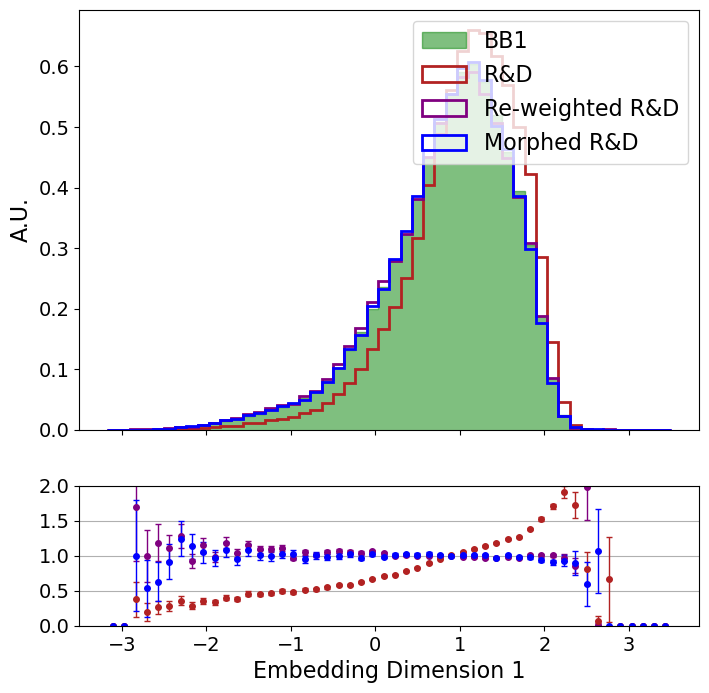

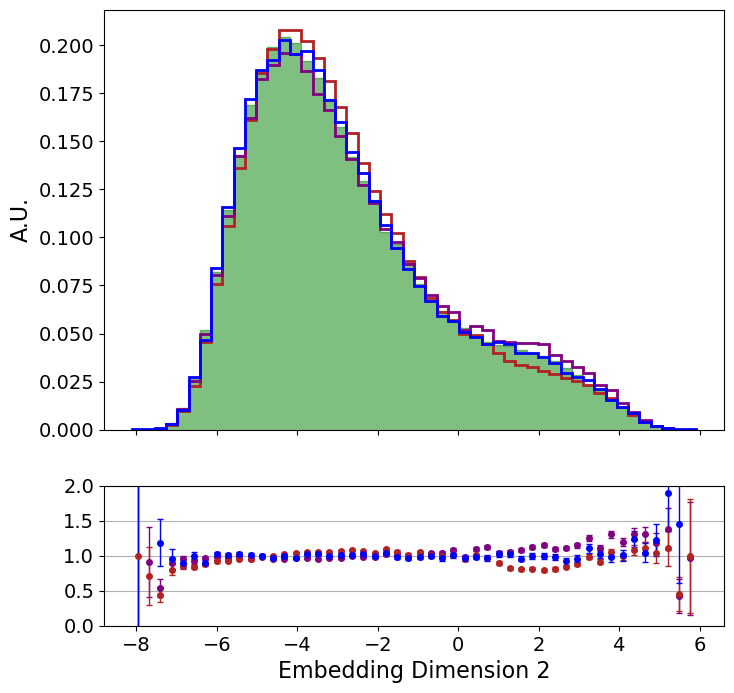

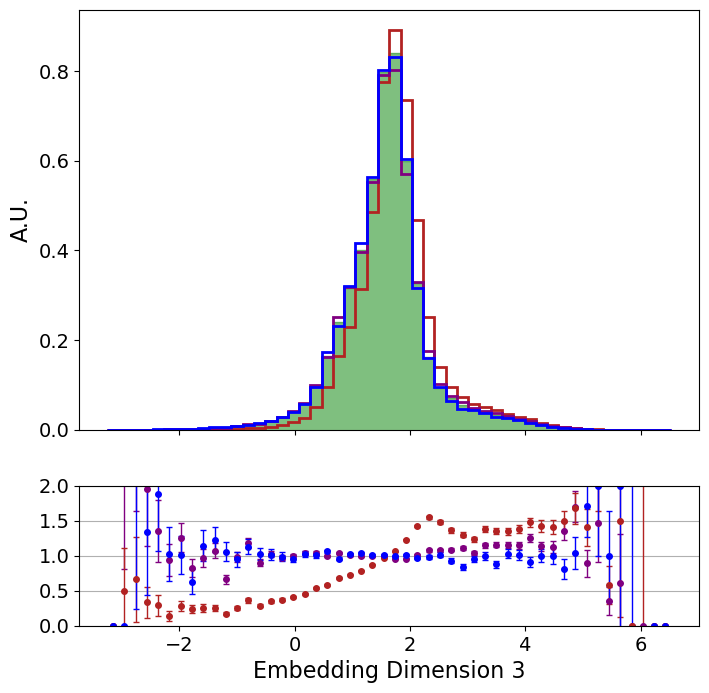

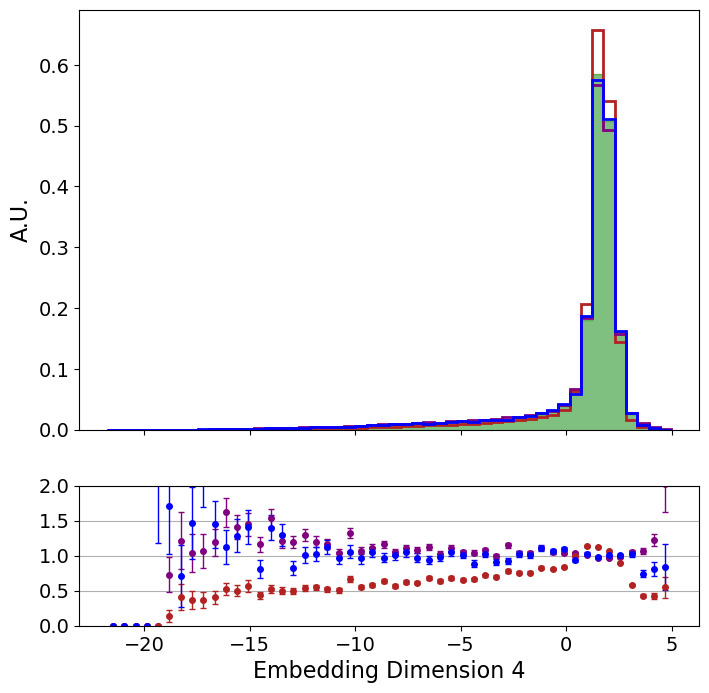

In [10]:
#xlims = [[0,0.6],[0,1],[0,1],[0.2,1]]
#xlims = xlims+xlims
msize=8
cthick=1
csize=2
elw = 1
varNames = ["Embedding Dimension 1","Embedding Dimension 2","Embedding Dimension 3","Embedding Dimension 4"]
fitvars = ['embed_1','embed_2','embed_3','embed_4']
import os
if not os.path.isdir("reweighting_methods/comparison_particleNet_jet1"):
    os.mkdir("reweighting_methods/comparison_particleNet_jet1")
for i in range(embed_rd.shape[1]):
    fig,axes = plt.subplots(figsize=(8,8),nrows=2,ncols=1,gridspec_kw={'height_ratios':[3,1]},sharex=True)
    plt.sca(axes[0])
    bins = 50
    h1,bins,_ = plt.hist(embed_b1[:,i],bins=bins,histtype='step',label='BB1',density=True,color='green',fill=True,alpha=0.5)
    h3,bins,_ = plt.hist(embed_rd[:,i],bins=bins,histtype='step',label='R&D',density=True,color='firebrick',linewidth=2)
    h2,bins,_ = plt.hist(embed_rd[:,i],weights=wgts_rd,bins=bins,histtype='step',label='Re-weighted R&D',density=True,color='purple',linewidth=2)
    h4,bins,_ = plt.hist(embed_rd_morph[:,i],bins=bins,histtype='step',label='Morphed R&D',density=True,color='blue',linewidth=2)
    h1c,bins = np.histogram(embed_b1[:,i],bins=bins)
    h3c,bins = np.histogram(embed_rd[:,i],bins=bins)
    h2c,bins = np.histogram(embed_rd[:,i],weights=wgts_rd,bins=bins)
    h4c,bins = np.histogram(embed_rd_morph[:,i],bins=bins)
    #plt.xlim(xlims[i])
    plt.ylabel("A.U.",fontsize=16)
    plt.yticks(fontsize=14)
    if i==0 or i==4:
        plt.legend(fontsize=16)
    plt.sca(axes[1])
    w = bins[1]-bins[0]
    c = (bins[1:]+bins[:-1])/2
    h = np.divide(h2,h1,where=h1>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,h2c.astype(np.float32),out=np.zeros_like(h2c.astype(np.float32)),where=h2c>0) + np.divide(1.0,h1c.astype(np.float32),out=np.zeros_like(h1c.astype(np.float32)),where=h1c>0))
    plt.errorbar(c,h,yerr=herr,color='purple',linewidth=0,markersize=msize,marker='.',elinewidth=elw,capsize=csize,capthick=cthick)
    h = np.divide(h3,h1,where=h1>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,h3c.astype(np.float32),out=np.zeros_like(h3c.astype(np.float32)),where=h3c>0) + np.divide(1.0,h1c.astype(np.float32),out=np.zeros_like(h1c.astype(np.float32)),where=h1c>0))
    plt.errorbar(c,h,yerr=herr,color='firebrick',linewidth=0,markersize=msize,marker='.',elinewidth=elw,capsize=csize,capthick=cthick)
    h = np.divide(h4,h1,where=h1>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,h4c.astype(np.float32),out=np.zeros_like(h4c.astype(np.float32)),where=h4c>0) + np.divide(1.0,h1c.astype(np.float32),out=np.zeros_like(h1c.astype(np.float32)),where=h1c>0))
    plt.errorbar(c,h,yerr=herr,color='blue',linewidth=0,markersize=msize,marker='.',elinewidth=elw,capsize=csize,capthick=cthick)
    #plt.xlim(xlims[i])
    plt.ylim([0,2])
    plt.yticks(np.arange(0,2.5,0.5),fontsize=14)
    plt.xticks(fontsize=14)
    plt.xlabel(varNames[i],fontsize=16)
    plt.grid(axis='y')
    plt.savefig(f"reweighting_methods/comparison_particleNet_jet1/{fitvars[i]}.pdf")

# Jets 1 + 2 high-level variables

In [3]:
# loading in test sets
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_ind_bb1 = f"{base}/challenge/BB1/split_indices.h5"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"
fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']
with h5py.File(f_ind_rd,'r') as f:
    rd_test_idx = f['test_inds'][()]
with h5py.File(f_ind_bb1,'r') as f:
    bb1_test_idx = f['test_inds'][()]
    
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    b1_test = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_test_idx]
    
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd_test = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_test_idx]

In [4]:
# correct with morphing
model_dir = "LHCO_BB1toPythRD_jets12"
corrector = qrnn.chainedNFCorrector(f"NF_models_QR_general/{model_dir}/")
corr_rd_test = corrector.invertFull(rd_test)
corr_rd_test = np.concatenate([corr_rd_test[v] for v in fitvars],axis=1)

# derive NN weights
with h5py.File("reweighting_methods/HL_meanStd_dnn.h5","r") as f:
    mean = f['mean'][()]
    std = f['std'][()]
wgt_net = torch.load("reweighting_methods/dnn_jets12_highLevel_toReweightRD.pt").to(device)
split = np.array_split(np.arange(rd_test.shape[0]),rd_test.shape[0]//10000)
rd_test_norm = (rd_test-mean)/std
wgts = []
for s in split:
    wgts.append(wgt_net(torch.tensor(rd_test_norm[s],dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0])
wgts = np.concatenate(wgts,axis=0)
wgts = wgts/(1-wgts)

[0, 1, 2, 3, 4, 5, 6]


100%|██████████| 26/26 [00:01<00:00, 13.04it/s]


[0, 1, 2, 3, 4, 5]


100%|██████████| 26/26 [00:00<00:00, 26.18it/s]


[0, 1, 2, 3, 4]


...

100%|██████████| 26/26 [00:00<00:00, 29.71it/s]


[0]


100%|██████████| 26/26 [00:00<00:00, 29.98it/s]


[]


100%|██████████| 26/26 [00:00<00:00, 29.84it/s]


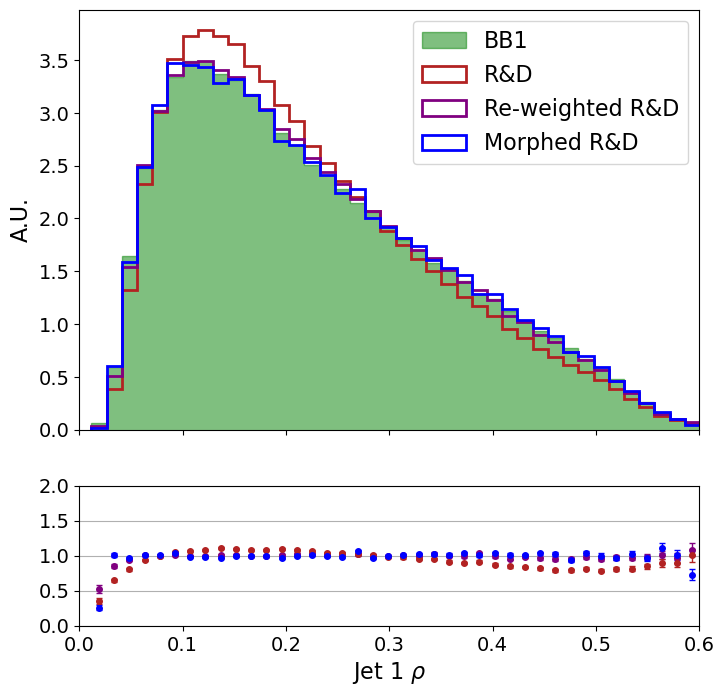

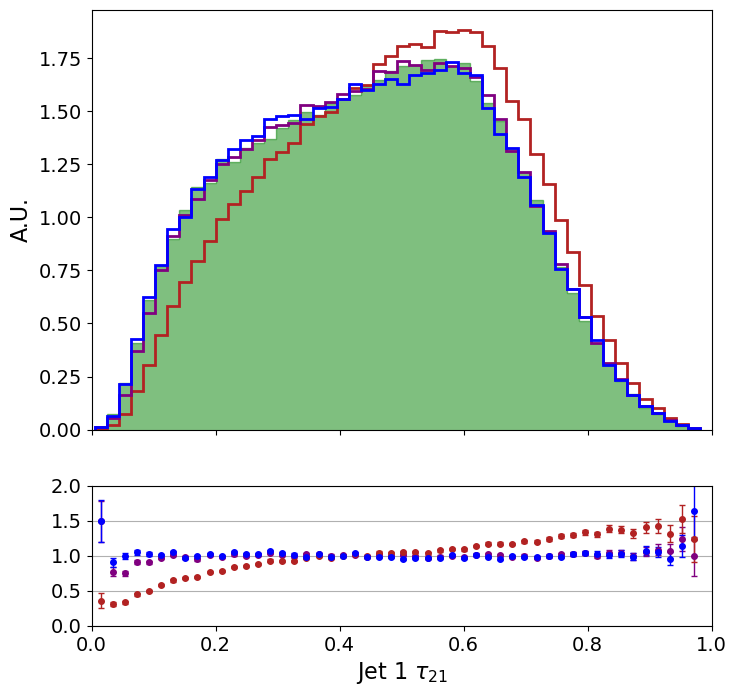

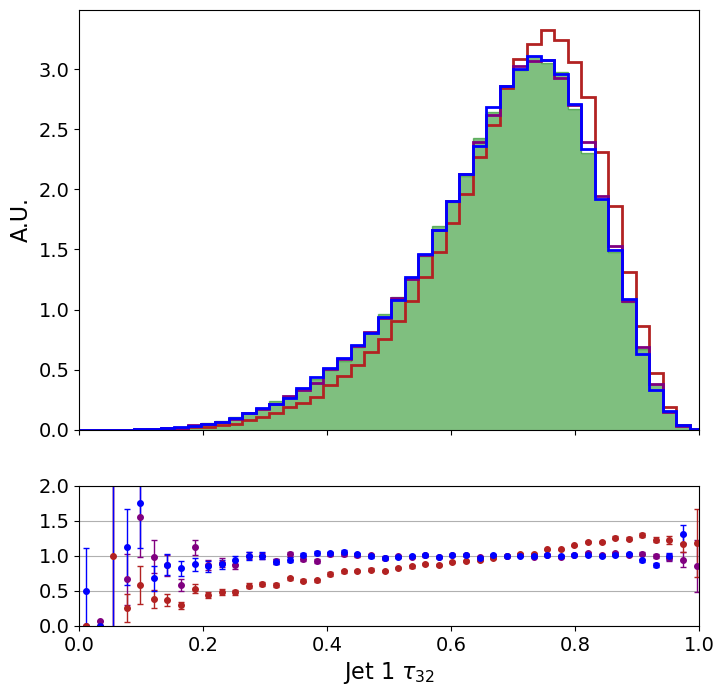

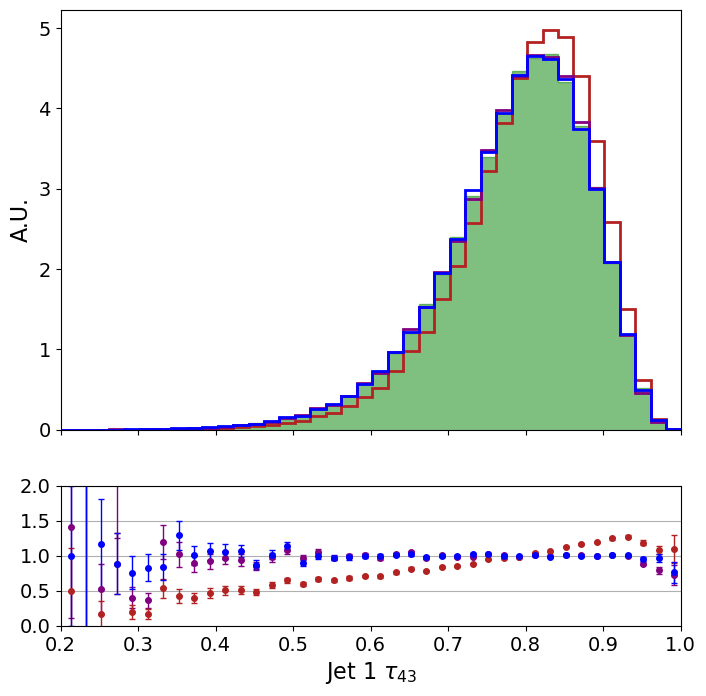

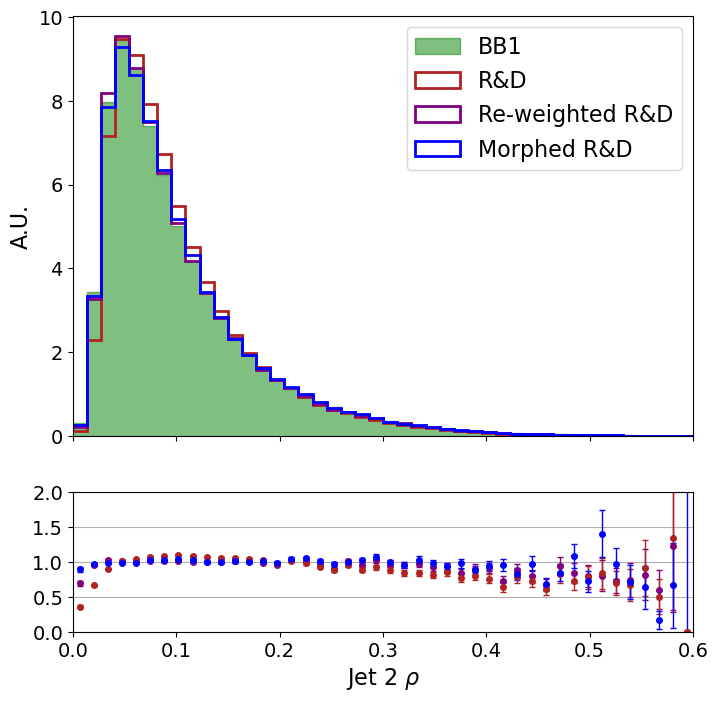

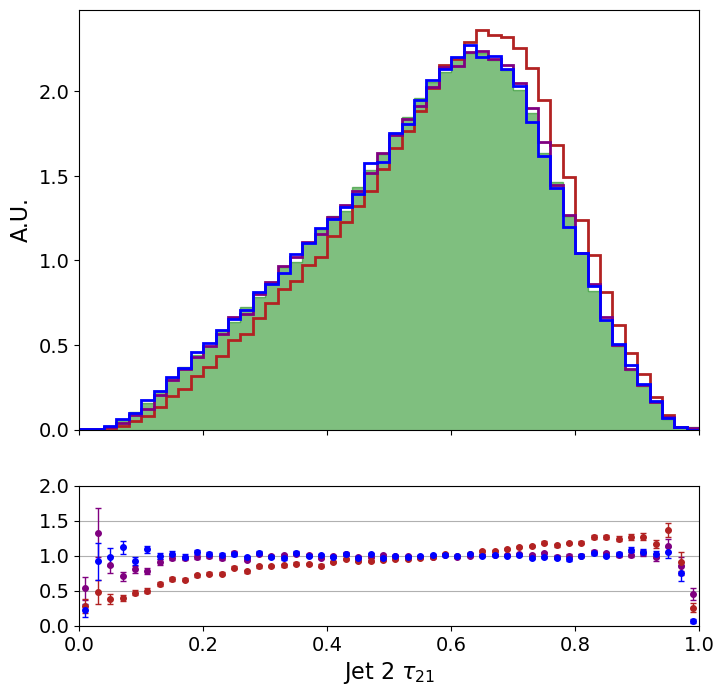

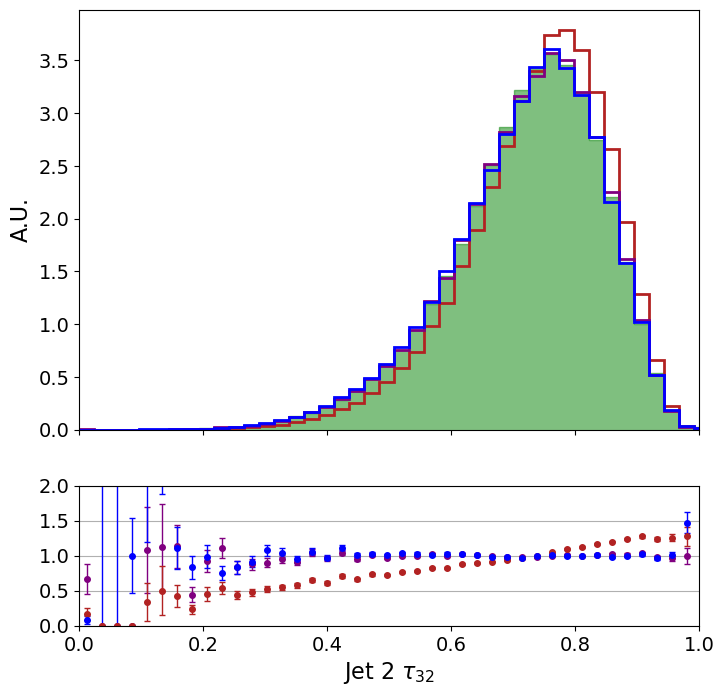

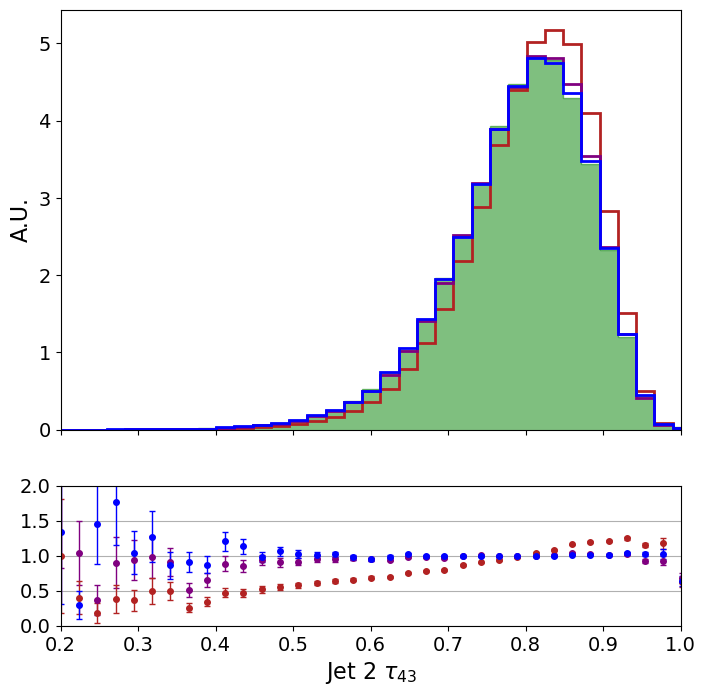

In [15]:
xlims = [[0,0.6],[0,1],[0,1],[0.2,1]]
xlims = xlims+xlims
msize=8
cthick=1
csize=2
elw = 1
varNames = [r"Jet 1 $\rho$",r"Jet 1 $\tau_{21}$",r"Jet 1 $\tau_{32}$",r"Jet 1 $\tau_{43}$",
            r"Jet 2 $\rho$",r"Jet 2 $\tau_{21}$",r"Jet 2 $\tau_{32}$",r"Jet 2 $\tau_{43}$"]
fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']
import os
if not os.path.isdir("reweighting_methods/comparison_highLevelNN_jets12"):
    os.mkdir("reweighting_methods/comparison_highLevelNN_jets12")
for i in range(rd_test.shape[1]):
    fig,axes = plt.subplots(figsize=(8,8),nrows=2,ncols=1,gridspec_kw={'height_ratios':[3,1]},sharex=True)
    plt.sca(axes[0])
    bins = 50
    h1,bins,_ = plt.hist(b1_test[:,i],bins=bins,histtype='step',label='BB1',density=True,color='green',fill=True,alpha=0.5)
    h3,bins,_ = plt.hist(rd_test[:,i],bins=bins,histtype='step',label='R&D',density=True,color='firebrick',linewidth=2)
    h2,bins,_ = plt.hist(rd_test[:,i],weights=wgts,bins=bins,histtype='step',label='Re-weighted R&D',density=True,color='purple',linewidth=2)
    h4,bins,_ = plt.hist(corr_rd_test[:,i],bins=bins,histtype='step',label='Morphed R&D',density=True,color='blue',linewidth=2)
    h1c,bins = np.histogram(b1_test[:,i],bins=bins)
    h3c,bins = np.histogram(rd_test[:,i],bins=bins)
    h2c,bins = np.histogram(rd_test[:,i],weights=wgts,bins=bins)
    h4c,bins = np.histogram(corr_rd_test[:,i],bins=bins)
    plt.xlim(xlims[i])
    plt.ylabel("A.U.",fontsize=16)
    plt.yticks(fontsize=14)
    if i==0 or i==4:
        plt.legend(fontsize=16)
    plt.sca(axes[1])
    w = bins[1]-bins[0]
    c = (bins[1:]+bins[:-1])/2
    h = np.divide(h2,h1,where=h1>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,h2c.astype(np.float32),out=np.zeros_like(h2c.astype(np.float32)),where=h2c>0) + np.divide(1.0,h1c.astype(np.float32),out=np.zeros_like(h1c.astype(np.float32)),where=h1c>0))
    plt.errorbar(c,h,yerr=herr,color='purple',linewidth=0,markersize=msize,marker='.',elinewidth=elw,capsize=csize,capthick=cthick)
    h = np.divide(h3,h1,where=h1>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,h3c.astype(np.float32),out=np.zeros_like(h3c.astype(np.float32)),where=h3c>0) + np.divide(1.0,h1c.astype(np.float32),out=np.zeros_like(h1c.astype(np.float32)),where=h1c>0))
    plt.errorbar(c,h,yerr=herr,color='firebrick',linewidth=0,markersize=msize,marker='.',elinewidth=elw,capsize=csize,capthick=cthick)
    h = np.divide(h4,h1,where=h1>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,h4c.astype(np.float32),out=np.zeros_like(h4c.astype(np.float32)),where=h4c>0) + np.divide(1.0,h1c.astype(np.float32),out=np.zeros_like(h1c.astype(np.float32)),where=h1c>0))
    plt.errorbar(c,h,yerr=herr,color='blue',linewidth=0,markersize=msize,marker='.',elinewidth=elw,capsize=csize,capthick=cthick)
    plt.xlim(xlims[i])
    plt.ylim([0,2])
    plt.yticks(np.arange(0,2.5,0.5),fontsize=14)
    plt.xticks(fontsize=14)
    plt.xlabel(varNames[i],fontsize=16)
    plt.grid(axis='y')
    plt.savefig(f"reweighting_methods/comparison_highLevelNN_jets12/{fitvars[i]}.pdf")